In [1]:
import torch

import sys
print(sys.executable)

print("Torch :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

c:\Users\mirza\anaconda3\envs\test1\python.exe
Torch : 2.5.1+cpu
CUDA available: False
GPU count: 0


import library

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import numpy as np

# ================= CONFIG =================
batch_size = 16
img_size = 224

train_dir = "C:/Users/mirza/Documents/Tugas/Skripsi/Dataset/nad"

# ================= TRANSFORMS =================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.02
    ),

    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

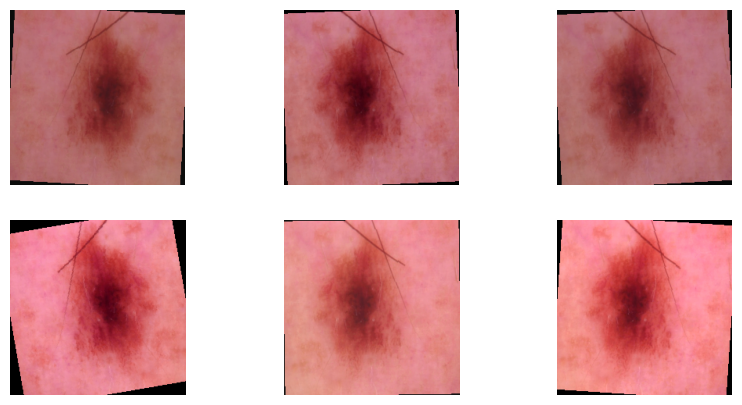

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean  # balik normalisasi
    img = np.clip(img, 0, 1)
    
    return img

def show_image(img_tensor, title=None):
    img = denormalize(img_tensor)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Ambil 1 gambar, tampilkan beberapa kali (augmentasi beda-beda)
plt.figure(figsize=(10, 5))

for i in range(6):
    img, label = train_dataset[0]  # ambil gambar yang sama
    plt.subplot(2, 3, i+1)
    show_image(img)

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.060536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9920369].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.0947855].


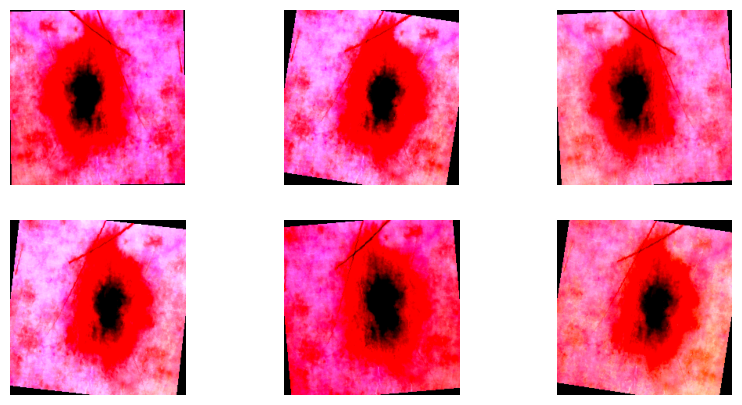

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def show_image(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))  # C,H,W → H,W,C
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Ambil 1 gambar, tampilkan beberapa kali (augmentasi beda-beda)
plt.figure(figsize=(10, 5))

for i in range(6):
    img, label = train_dataset[0]  # ambil gambar yang sama
    plt.subplot(2, 3, i+1)
    show_image(img)

plt.show()

In [6]:
!pip install transformers

   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   -------- ------------------------------- 2.1/10.2 MB 10.7 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/10.2 MB 9.1 MB/s eta 0:00:01
   ------------------ --------------------- 4.7/10.2 MB 7.7 MB/s eta 0:00:01
   ---------------------- ----------------- 5.8/10.2 MB 6.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.8/10.2 MB 6.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.9/10.2 MB 6.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.9/10.2 MB 6.2 MB/s eta 0:00:01
   -------------------------------------- - 10.0/10.2 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 5.8 MB/s  0:00:01
   ---------------------------------------- 0.0/637.4 kB ? eta -:--:--
   ---------------------------------------- 637.4/637.4 kB 4.0 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ----------- -----

ImportError: cannot import name 'transformers' from 'torchvision' (C:\Users\mirza\AppData\Roaming\Python\Python312\site-packages\torchvision\__init__.py)

In [3]:
# ============================================================
# 1. PATH DATA
# ============================================================
DATA_DIR = r"C:\Users\risuser\Documents\HAM10000"
IMG1 = os.path.join(DATA_DIR, "HAM10000_images_part_1")
IMG2 = os.path.join(DATA_DIR, "HAM10000_images_part_2")
META = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

In [4]:
# ============================================================
# 2. LOAD METADATA
# ============================================================
df = pd.read_csv(META)

# Tambahkan kolom path image
df["path"] = df["image_id"].apply(
    lambda x: os.path.join(IMG1, x + ".jpg")
    if os.path.exists(os.path.join(IMG1, x + ".jpg"))
    else os.path.join(IMG2, x + ".jpg")
)

### label mapping

In [5]:
# Label map
label_mapping = {label: idx for idx, label in enumerate(df["dx"].unique())}
df["label"] = df["dx"].map(label_mapping)

num_classes = len(label_mapping)
print("Classes:", label_mapping)

Classes: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [2]:
minor_classes = ['2', '4', '6']
major_classes = ['0', '1', '3', '5']

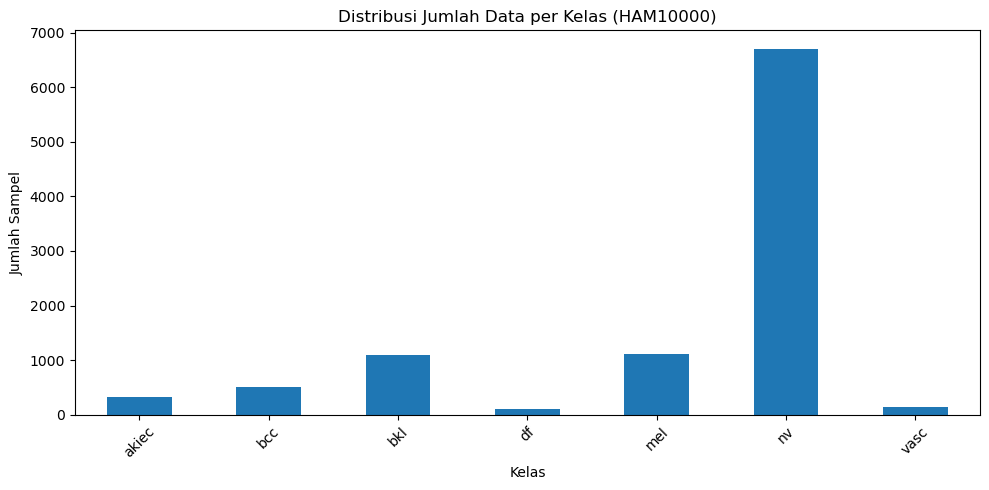

label
0    1099
1    6705
2     115
3    1113
4     142
5     514
6     327
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

counts = df['dx'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
counts.plot(kind='bar')

plt.title("Distribusi Jumlah Data per Kelas (HAM10000)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

jumlah_per_kelas = df["label"].value_counts().sort_index()
print(jumlah_per_kelas)

In [7]:
# ============================================================
# 3. SPLIT DATA 80-10-10
# ============================================================
train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(len(train_df), len(val_df), len(test_df))

8012 1001 1002


In [8]:
# ============================================================
# 6. OVERSAMPLING (WeightedRandomSampler)
# ============================================================
class_counts = train_df["label"].value_counts().sort_index().tolist()
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = weights[train_df["label"].values]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

### jumlah data per kelas (after splitting)

In [9]:
class_counts = train_df["label"].value_counts().sort_index()

print("Jumlah sampel per kelas:")
for cls, count in class_counts.items():
    print(f"Kelas {cls}: {count}")

Jumlah sampel per kelas:
Kelas 0: 879
Kelas 1: 5364
Kelas 2: 92
Kelas 3: 890
Kelas 4: 114
Kelas 5: 411
Kelas 6: 262


### distribusi data

In [10]:
import numpy as np

# Ambil indeks hasil oversampling
sampled_indices = list(sampler)

# Ambil label berdasarkan indeks tersebut
oversampled_labels = train_df.iloc[sampled_indices]["label"]

oversampled_counts = oversampled_labels.value_counts().sort_index()

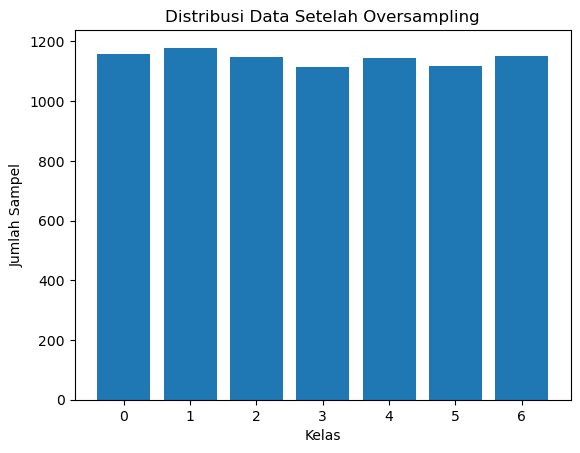

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    oversampled_counts.index,
    oversampled_counts.values
)
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi Data Setelah Oversampling")
plt.show()

In [3]:
from torchvision import transforms

# Normalisasi standar ImageNet (dipakai oleh ViT pretrained)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Val dan Test tidak ada augmentasi
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

Classes: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


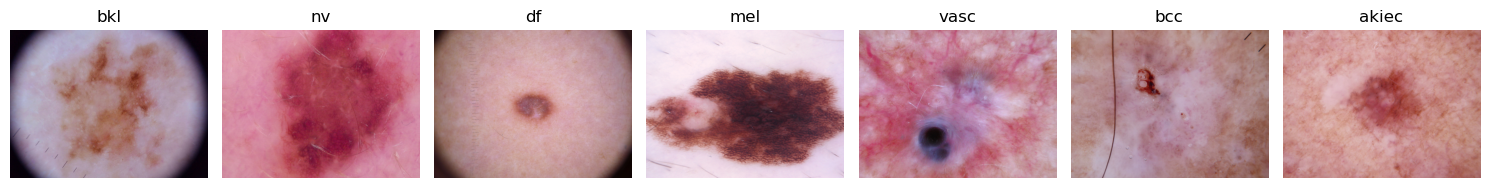

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

classes = df['dx'].unique()
print("Classes:", classes)

plt.figure(figsize=(15, 4))

for i, cls in enumerate(classes):
    sample = df[df['dx'] == cls].sample(1).iloc[0]
    img_path = sample["path"]    

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
from transformers import ViTImageProcessor
from transformers import ViTForImageClassification

# ============================================================
# 4. IMAGE PROCESSOR (ViT Pretrained)
# ============================================================
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
from torchvision import transforms

from transformers import ViTImageProcessor
from transformers import ViTForImageClassification

# ============================================================
# 4. IMAGE PROCESSOR (ViT Pretrained)
# ============================================================
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# Transform untuk training (augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.02
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    )
])


ModuleNotFoundError: No module named 'transformers'

In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
# ============================================================
# 5. DATASET CLASS
# ============================================================
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "label"]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

train_ds = HAMDataset(train_df, train_transform)
val_ds   = HAMDataset(val_df, test_transform)
test_ds  = HAMDataset(test_df, test_transform)

In [ ]:
# ============================================================
# 7. DATALOADER
# ============================================================
batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [19]:
# ============================================================
# 8. LOAD PRETRAINED VIT BASE
# ============================================================
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=num_classes
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device yang digunakan:", device)

Device yang digunakan: cuda


### training model

C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/20
Train Loss: 1.3492 | Val Loss: 0.9111
Train Acc: 0.6216 | Val Acc: 0.7542
Precision: 0.4847 | Recall: 0.4973 | F1-score: 0.4655
🔥 Best model saved


C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 2/20
Train Loss: 0.6098 | Val Loss: 0.7281
Train Acc: 0.8662 | Val Acc: 0.8002
Precision: 0.7092 | Recall: 0.7055 | F1-score: 0.6730
🔥 Best model saved


C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...


Epoch 18/20
Train Loss: 0.2562 | Val Loss: 0.6321
Train Acc: 0.9994 | Val Acc: 0.8951
Precision: 0.8361 | Recall: 0.7691 | F1-score: 0.7990


C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 19/20
Train Loss: 0.2559 | Val Loss: 0.6097
Train Acc: 0.9994 | Val Acc: 0.8991
Precision: 0.8536 | Recall: 0.7762 | F1-score: 0.8111
🔥 Best model saved


C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\2535188562.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 20/20
Train Loss: 0.2552 | Val Loss: 0.6087
Train Acc: 0.9995 | Val Acc: 0.9001
Precision: 0.8690 | Recall: 0.7922 | F1-score: 0.8268
🔥 Best model saved

🎉 Training finished
🏆 Best Epoch: 20
📉 Best Val Loss: 0.6087


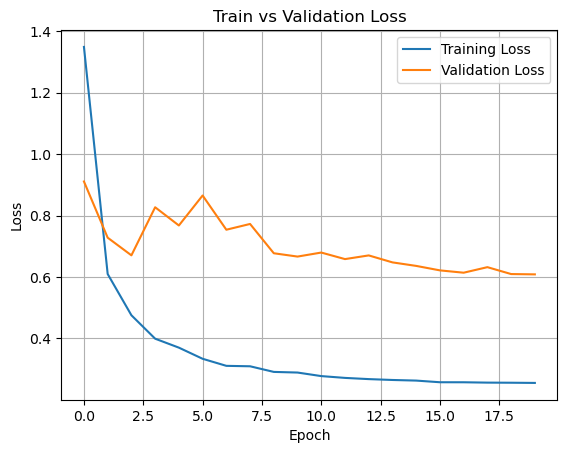

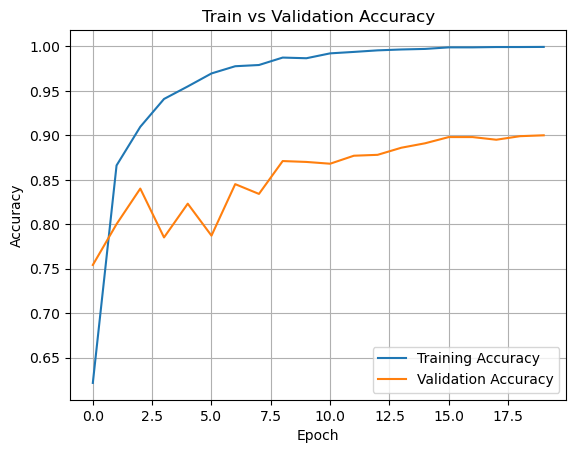

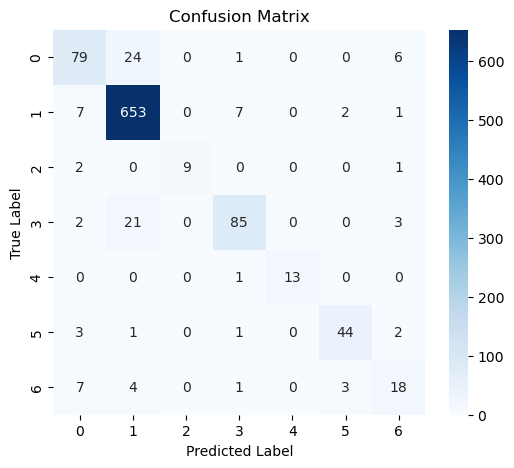

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from torch.cuda.amp import autocast, GradScaler
from transformers import get_cosine_schedule_with_warmup

# ===================== DEVICE =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ===================== DROPOUT (DROP RATE) =====================
# Tambahkan dropout di classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),  # DROP RATE
    nn.Linear(model.classifier.in_features, num_classes)
).to(device)

# ===================== LOSS & OPTIMIZER =====================
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.001
)

epochs = 20
scaler = GradScaler()

num_training_steps = len(train_loader) * epochs
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)

# ===================== SIMPAN METRIK =====================
train_losses = []
val_losses = []
train_accs = []
val_accs = []
val_f1s = []

best_val_loss = float("inf")
best_epoch = 0

# ===================== TRAINING LOOP =====================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs.logits, labels)

        preds = outputs.logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs.logits, labels)

            preds = outputs.logits.argmax(dim=1)

            val_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    precision = precision_score(val_labels, val_preds, average="macro", zero_division=0)
    recall = recall_score(val_labels, val_preds, average="macro", zero_division=0)
    f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

    val_f1s.append(f1)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print("🔥 Best model saved")

print("\n🎉 Training finished")
print(f"🏆 Best Epoch: {best_epoch}")
print(f"📉 Best Val Loss: {best_val_loss:.4f}")

# ===================== VISUALISASI =====================

# 1️⃣ Train vs Validation Loss
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Train vs Validation Accuracy
plt.figure()
plt.plot(train_accs, label="Training Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 4️⃣ Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


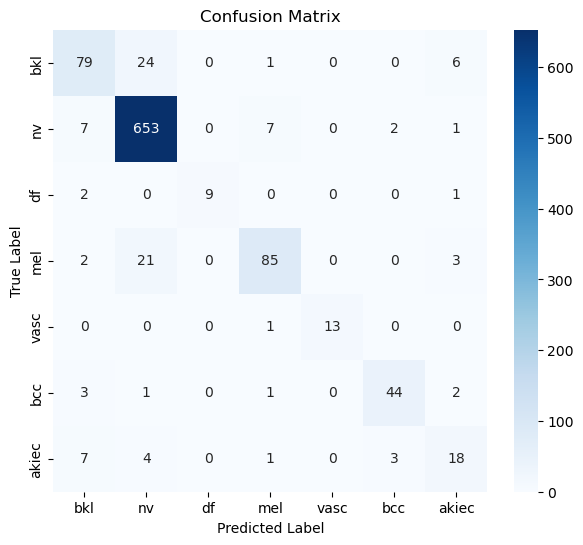

In [22]:
class_names = [
    "bkl",    # 0
    "nv",     # 1
    "df",     # 2
    "mel",    # 3
    "vasc",   # 4
    "bcc",    # 5
    "akiec"   # 6
]

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\3163214989.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_lo

✅ Best model loaded successfully


C:\Users\risuser\AppData\Local\Temp\ipykernel_18764\3163214989.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



📊 TEST SET PERFORMANCE
Accuracy  : 0.9012
Precision : 0.8283
Recall    : 0.7797
F1-score  : 0.8007


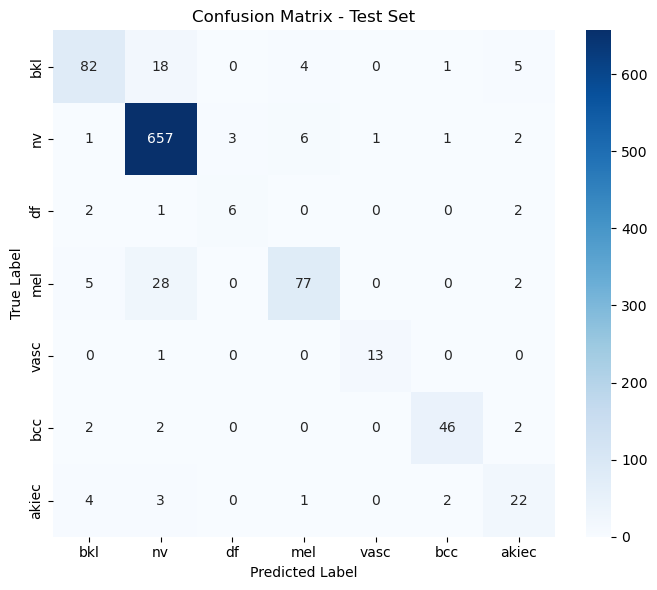

In [23]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from torch.cuda.amp import autocast

# ===================== DEVICE =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== LOAD MODEL (TANPA UBAH CLASSIFIER) =====================
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Best model loaded successfully")

# ===================== TESTING LOOP =====================
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        with autocast():
            outputs = model(images)

        preds = outputs.logits.argmax(dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# ===================== METRIC EVALUATION =====================
acc = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
recall = recall_score(test_labels, test_preds, average="macro", zero_division=0)
f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)

print("\n📊 TEST SET PERFORMANCE")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

### classfication report

In [24]:
import torch
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        logits = outputs.logits             
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.8632    0.7455    0.8000       110
           1     0.9271    0.9851    0.9552       671
           2     0.7500    0.5455    0.6316        11
           3     0.8750    0.6875    0.7700       112
           4     0.9286    0.9286    0.9286        14
           5     0.9200    0.8846    0.9020        52
           6     0.6471    0.6875    0.6667        32

    accuracy                         0.9052      1002
   macro avg     0.8444    0.7806    0.8077      1002
weighted avg     0.9030    0.9052    0.9016      1002



In [25]:
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       akiec     0.8632    0.7455    0.8000       110
         bcc     0.9271    0.9851    0.9552       671
         bkl     0.7500    0.5455    0.6316        11
          df     0.8750    0.6875    0.7700       112
         mel     0.9286    0.9286    0.9286        14
          nv     0.9200    0.8846    0.9020        52
        vasc     0.6471    0.6875    0.6667        32

    accuracy                         0.9052      1002
   macro avg     0.8444    0.7806    0.8077      1002
weighted avg     0.9030    0.9052    0.9016      1002



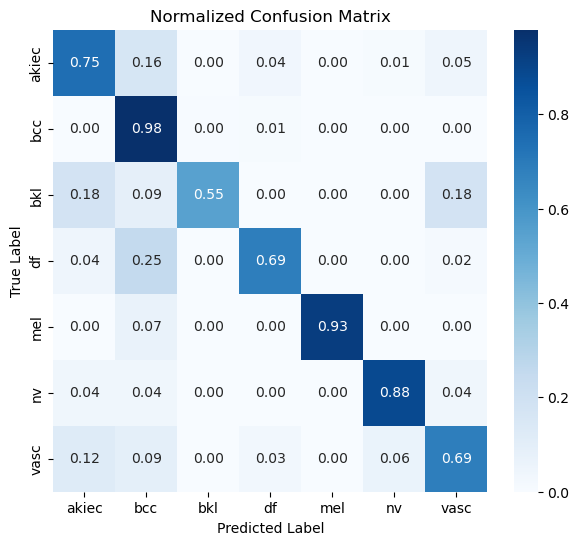

In [26]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()


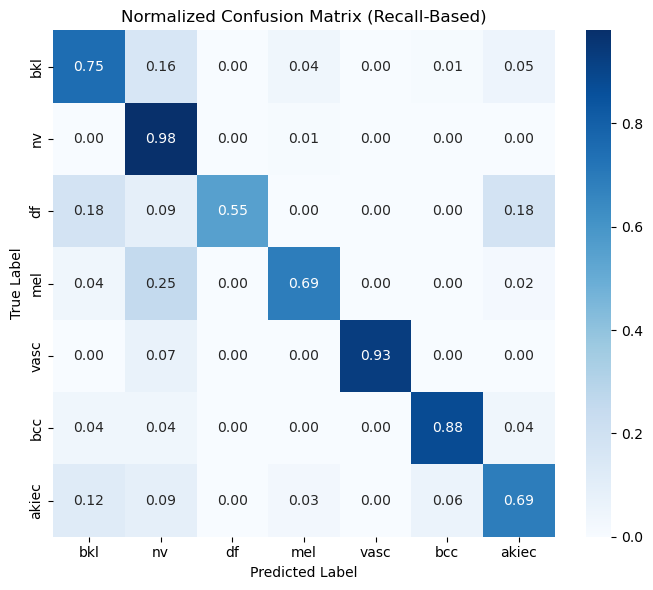

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm_norm = np.array([
    [0.75, 0.16, 0.00, 0.04, 0.00, 0.01, 0.05],
    [0.00, 0.98, 0.00, 0.01, 0.00, 0.00, 0.00],
    [0.18, 0.09, 0.55, 0.00, 0.00, 0.00, 0.18],
    [0.04, 0.25, 0.00, 0.69, 0.00, 0.00, 0.02],
    [0.00, 0.07, 0.00, 0.00, 0.93, 0.00, 0.00],
    [0.04, 0.04, 0.00, 0.00, 0.00, 0.88, 0.04],
    [0.12, 0.09, 0.00, 0.03, 0.00, 0.06, 0.69],
])

class_names = ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Recall-Based)")
plt.tight_layout()
plt.show()


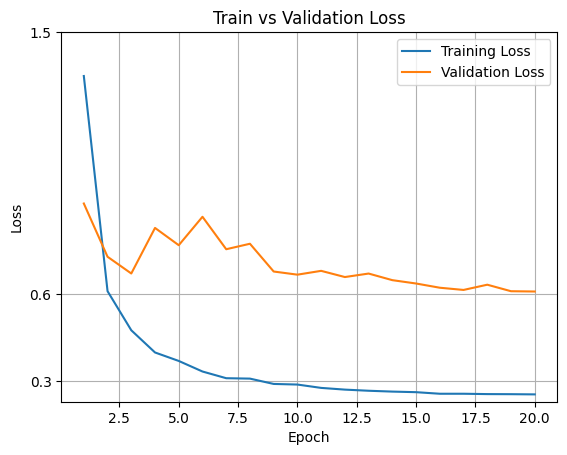

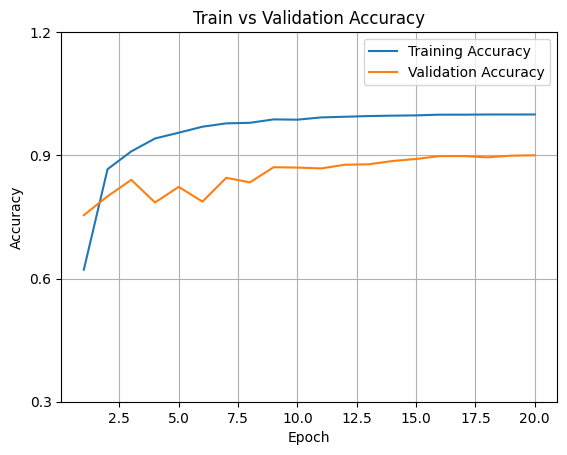

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ===================== DATA =====================
epochs = np.arange(1, 21)

train_loss = [
    1.3492, 0.6098, 0.4755, 0.3992, 0.3701,
    0.3338, 0.3108, 0.3094, 0.2911, 0.2890,
    0.2775, 0.2716, 0.2677, 0.2648, 0.2628,
    0.2574, 0.2574, 0.2562, 0.2559, 0.2552
]

val_loss = [
    0.9111, 0.7281, 0.6706, 0.8272, 0.7678,
    0.8655, 0.7540, 0.7728, 0.6774, 0.6666,
    0.6797, 0.6584, 0.6704, 0.6477, 0.6362,
    0.6217, 0.6141, 0.6321, 0.6097, 0.6087
]

train_acc = [
    0.6216, 0.8662, 0.9096, 0.9410, 0.9551,
    0.9697, 0.9778, 0.9792, 0.9875, 0.9868,
    0.9923, 0.9939, 0.9956, 0.9966, 0.9973,
    0.9990, 0.9990, 0.9994, 0.9994, 0.9995
]

val_acc = [
    0.7542, 0.8002, 0.8402, 0.7852, 0.8232,
    0.7872, 0.8452, 0.8342, 0.8711, 0.8701,
    0.8681, 0.8771, 0.8781, 0.8861, 0.8911,
    0.8981, 0.8981, 0.8951, 0.8991, 0.9001
]

# ===================== LOSS PLOT =====================
plt.figure()
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")

# 🔥 ZOOM Y-AXIS (BIAR GAP KELIHATAN)
plt.ylim(0.23, 0.95)
plt.yticks([0.3, 0.6, 1.5])

plt.legend()
plt.grid(True)
plt.show()

# ===================== ACCURACY PLOT =====================
plt.figure()
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")

# 🔥 ZOOM ACCURACY
plt.ylim(0.74, 1.01)
plt.yticks([0.3, 0.6, 0.9, 1.2])

plt.legend()
plt.grid(True)
plt.show()


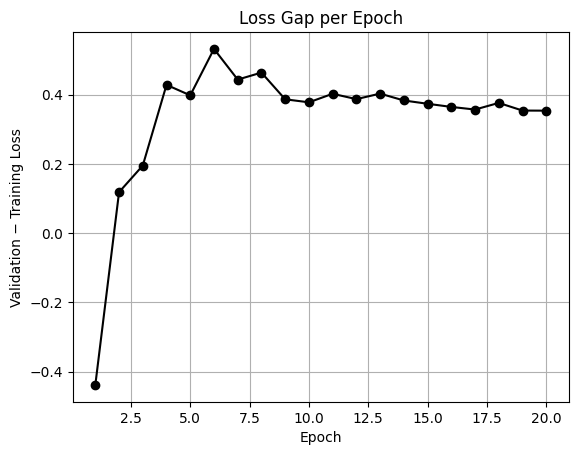

In [5]:
gap_loss = [v - t for v, t in zip(val_loss, train_loss)]

plt.figure()
plt.plot(epochs, gap_loss, marker="o", color="black")

plt.xlabel("Epoch")
plt.ylabel("Validation − Training Loss")
plt.title("Loss Gap per Epoch")
plt.grid(True)
plt.show()


In [21]:
import numpy as np
import pandas as pd

# ===================== INPUT =====================
class_names = ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']

cm_norm = np.array([
    [0.75, 0.16, 0.00, 0.04, 0.00, 0.01, 0.05],
    [0.00, 0.98, 0.00, 0.01, 0.00, 0.00, 0.00],
    [0.18, 0.09, 0.55, 0.00, 0.00, 0.00, 0.18],
    [0.04, 0.25, 0.00, 0.69, 0.00, 0.00, 0.02],
    [0.00, 0.07, 0.00, 0.00, 0.93, 0.00, 0.00],
    [0.04, 0.04, 0.00, 0.00, 0.00, 0.88, 0.04],
    [0.12, 0.09, 0.00, 0.03, 0.00, 0.06, 0.69]
])

# ===================== EXTRACT MISCLASSIFICATION =====================
misclassified = []

for i, true_label in enumerate(class_names):
    for j, pred_label in enumerate(class_names):
        if i != j and cm_norm[i, j] > 0:
            misclassified.append({
                'True Label': true_label,
                'Predicted As': pred_label,
                'Misclassification Rate': cm_norm[i, j]
            })

df_mis = pd.DataFrame(misclassified)

# Sort dari yang terbesar
df_mis = df_mis.sort_values(
    by='Misclassification Rate',
    ascending=False
).reset_index(drop=True)

print(df_mis)


   True Label Predicted As  Misclassification Rate
0         mel           nv                    0.25
1          df          bkl                    0.18
2          df        akiec                    0.18
3         bkl           nv                    0.16
4       akiec          bkl                    0.12
5          df           nv                    0.09
6       akiec           nv                    0.09
7        vasc           nv                    0.07
8       akiec          bcc                    0.06
9         bkl        akiec                    0.05
10        mel          bkl                    0.04
11        bkl          mel                    0.04
12        bcc          bkl                    0.04
13        bcc           nv                    0.04
14        bcc        akiec                    0.04
15      akiec          mel                    0.03
16        mel        akiec                    0.02
17         nv          mel                    0.01
18        bkl          bcc     

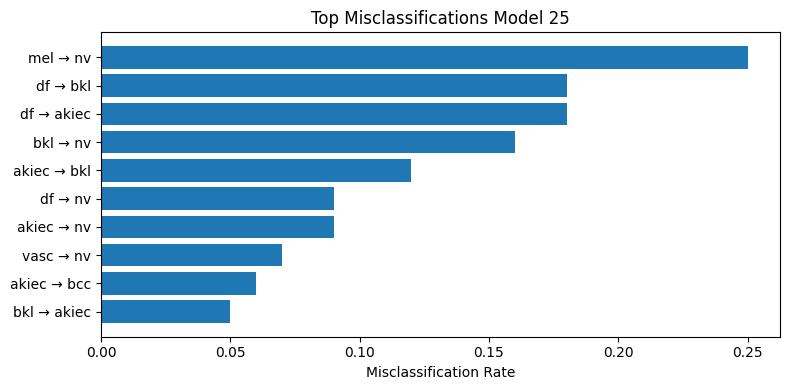

In [23]:
import matplotlib.pyplot as plt

top_k = 10
df_top = df_mis.head(top_k)

plt.figure(figsize=(8, 4))
plt.barh(
    df_top['True Label'] + ' → ' + df_top['Predicted As'],
    df_top['Misclassification Rate']
)
plt.xlabel('Misclassification Rate')
plt.title('Top Misclassifications Model 25')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


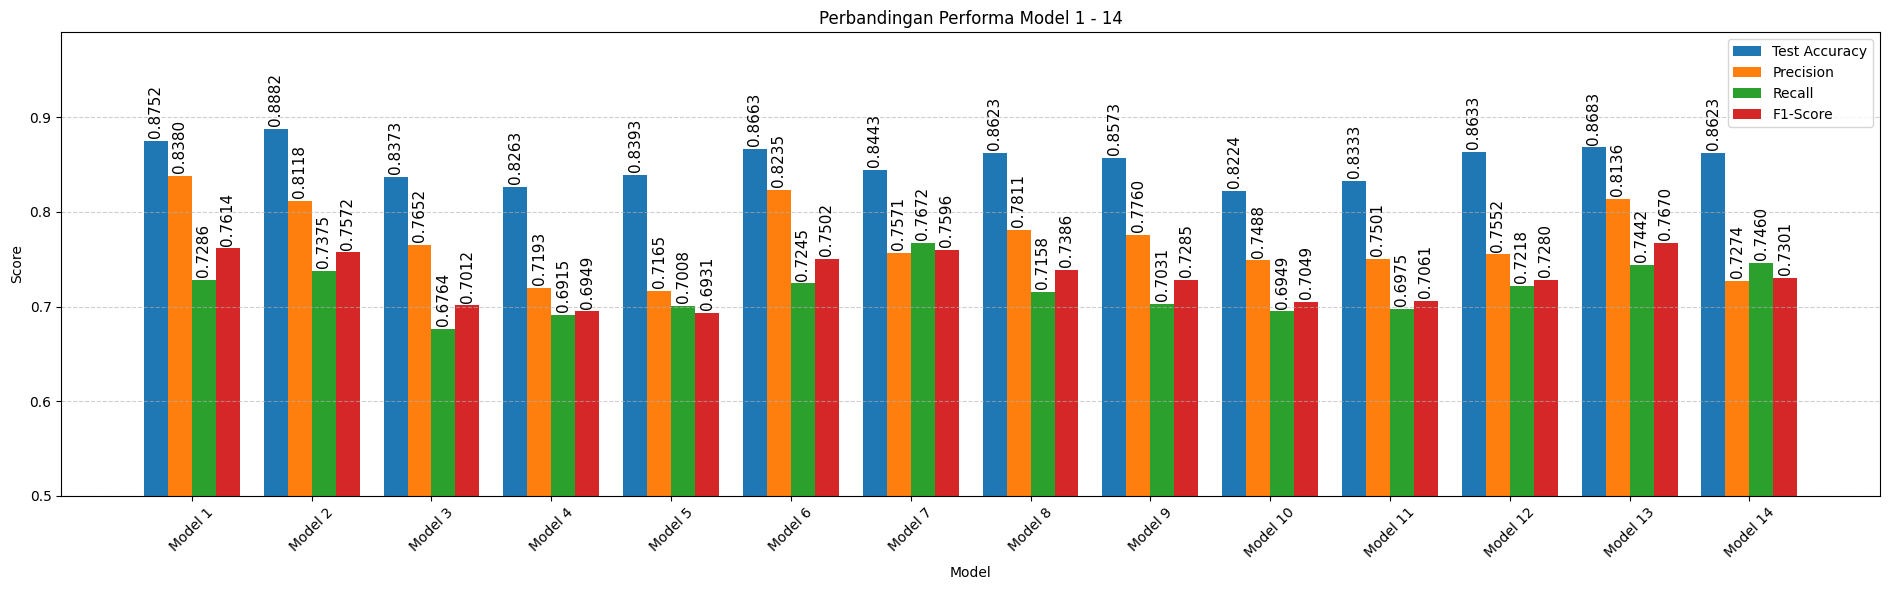

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data 14 model
# =========================
models = [f"Model {i}" for i in range(1, 15)]

test_acc = [
    0.8752, 0.8882, 0.8373, 0.8263, 0.8393, 0.8663, 0.8443,
    0.8623, 0.8573, 0.8224, 0.8333, 0.8633, 0.8683, 0.8623
]

precision = [
    0.8380, 0.8118, 0.7652, 0.7193, 0.7165, 0.8235, 0.7571,
    0.7811, 0.7760, 0.7488, 0.7501, 0.7552, 0.8136, 0.7274
]

recall = [
    0.7286, 0.7375, 0.6764, 0.6915, 0.7008, 0.7245, 0.7672,
    0.7158, 0.7031, 0.6949, 0.6975, 0.7218, 0.7442, 0.7460
]

f1_score = [
    0.7614, 0.7572, 0.7012, 0.6949, 0.6931, 0.7502, 0.7596,
    0.7386, 0.7285, 0.7049, 0.7061, 0.7280, 0.7670, 0.7301
]

# =========================
# Plot
# =========================
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(19, 6))

bars1 = plt.bar(x - 1.5*width, test_acc, width, label="Test Accuracy")
bars2 = plt.bar(x - 0.5*width, precision, width, label="Precision")
bars3 = plt.bar(x + 0.5*width, recall, width, label="Recall")
bars4 = plt.bar(x + 1.5*width, f1_score, width, label="F1-Score")

# =========================
# Tambahkan angka di ujung bar
# =========================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.003,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=11,
            rotation=90
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# =========================
# Styling
# =========================
plt.xticks(x, models, rotation=45)
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Perbandingan Performa Model 1 - 14")
plt.ylim(0.50, 0.99)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


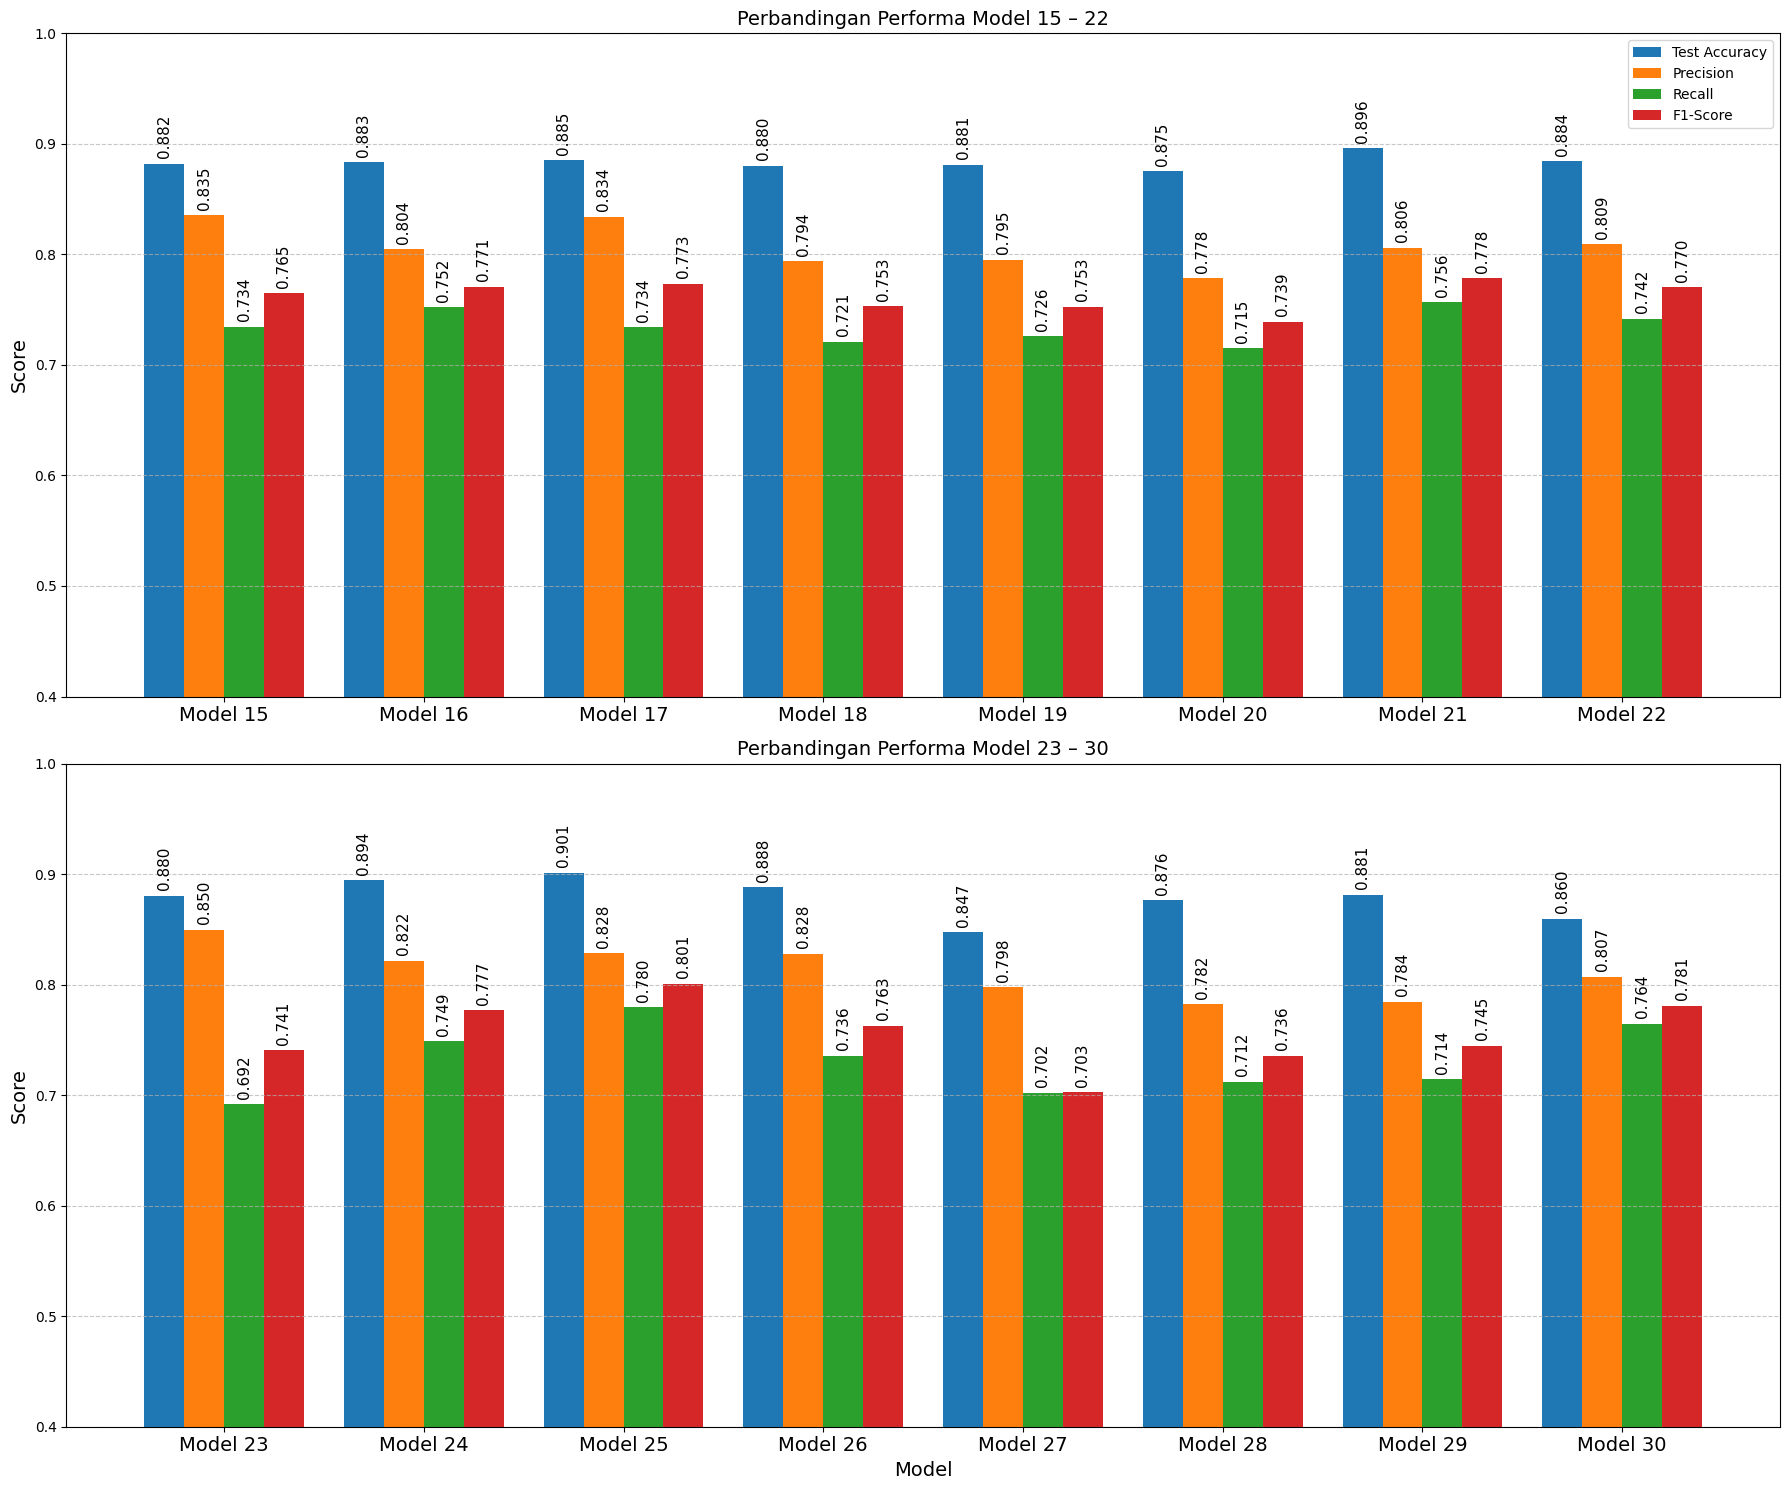

In [29]:
# ===================== DATA =====================
test_acc = [
    0.8822, 0.8832, 0.8852, 0.8802, 0.8812, 0.8752, 0.8962,
    0.8842, 0.8802, 0.8942, 0.9012, 0.8882, 0.8473, 0.8762,
    0.8812, 0.8596
]

precision = [
    0.8354, 0.8045, 0.8339, 0.7936, 0.7953, 0.7782, 0.8062,
    0.8092, 0.8497, 0.8217, 0.8283, 0.8277, 0.7976, 0.7821,
    0.7843, 0.8071
]

recall = [
    0.7344, 0.7520, 0.7340, 0.7209, 0.7259, 0.7152, 0.7565,
    0.7417, 0.6916, 0.7486, 0.7797, 0.7356, 0.7023, 0.7120,
    0.7144, 0.7645
]

f1_score = [
    0.7647, 0.7709, 0.7735, 0.7529, 0.7527, 0.7392, 0.7785,
    0.7701, 0.7407, 0.7766, 0.8007, 0.7627, 0.7027, 0.7357,
    0.7446, 0.7809
]

# ===================== LABEL MODEL =====================
models = [f"Model {i}" for i in range(15, 31)]

models_top = models[:8]      # Model 15–22
models_bottom = models[8:]   # Model 23–30

metrics_top = [test_acc[:8], precision[:8], recall[:8], f1_score[:8]]
metrics_bottom = [test_acc[8:], precision[8:], recall[8:], f1_score[8:]]

labels = ["Test Accuracy", "Precision", "Recall", "F1-Score"]

# ===================== FUNCTION LABEL BAR =====================
def add_value_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            rotation=90
        )

# ===================== PLOTTING =====================
fig, axes = plt.subplots(2, 1, figsize=(18, 15), sharey=True)

bar_width = 0.2
x_top = np.arange(len(models_top))
x_bottom = np.arange(len(models_bottom))

# -------- BARIS ATAS --------
for i, metric in enumerate(metrics_top):
    bars = axes[0].bar(
        x_top + i * bar_width,
        metric,
        bar_width,
        label=labels[i]
    )
    add_value_labels(axes[0], bars)

axes[0].set_title("Perbandingan Performa Model 15 – 22", fontsize=14)
axes[0].set_xticks(x_top + 1.5 * bar_width)
axes[0].set_xticklabels(models_top, fontsize=14)
axes[0].set_ylabel("Score", fontsize=14)
axes[0].set_ylim(0.40, 1.0)
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# -------- BARIS BAWAH --------
for i, metric in enumerate(metrics_bottom):
    bars = axes[1].bar(
        x_bottom + i * bar_width,
        metric,
        bar_width
    )
    add_value_labels(axes[1], bars)

axes[1].set_title("Perbandingan Performa Model 23 – 30", fontsize=14)
axes[1].set_xticks(x_bottom + 1.5 * bar_width)
axes[1].set_xticklabels(models_bottom, fontsize=14)
axes[1].set_ylabel("Score", fontsize=14)
axes[1].set_xlabel("Model", fontsize=14)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
